#

## Data Preparation

In [25]:
import io
import os
import zipfile
from datetime import timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import vectorbt as vbt

from openbb import obb

obb.user.preferences.output_type = "dataframe"

# --- Crypto source: Binance public data dumps (data.binance.vision) ---
# OpenBB/yfinance caps intraday history (1h ~730 days, 1m ~8 days), but
# Binance serves full kline archives (1m back to 2017) as zip files —
# no API key, no rate limit. Same source the DGT paper used.
# Note: timestamps switched from milliseconds to microseconds in 2025 files.
_BINANCE_VISION = "https://data.binance.vision/data/spot/{span}/klines/{symbol}/{interval}"
_KLINE_COLS = ["open_time", "open", "high", "low", "close", "volume", "close_time",
               "quote_volume", "trades", "taker_base_vol", "taker_quote_vol", "ignore"]


def _fetch_kline_zip(url: str, cache_dir: str) -> pd.DataFrame | None:
    """Download (or reuse cached) kline zip; None if the file doesn't exist."""
    cache_path = os.path.join(cache_dir, url.rsplit("/", 1)[-1])
    if os.path.exists(cache_path):
        raw = open(cache_path, "rb").read()
    else:
        r = requests.get(url, timeout=120)
        if r.status_code == 404:
            return None
        r.raise_for_status()
        raw = r.content
        with open(cache_path, "wb") as f:
            f.write(raw)
    zf = zipfile.ZipFile(io.BytesIO(raw))
    df = pd.read_csv(zf.open(zf.namelist()[0]), header=None, names=_KLINE_COLS)
    df = df[pd.to_numeric(df["open_time"], errors="coerce").notna()]  # drop header row if present
    return df


def load_binance_klines(symbol: str = "BTCUSDT", interval: str = "1m",
                        start: str = "2025-01-01", end: str | None = None,
                        cache_dir: str = "binance_cache") -> pd.DataFrame:
    """
    Load OHLCV klines from data.binance.vision bulk archives.

    Complete months come from monthly zips, the current month from daily
    zips (published with ~1 day lag). Zips are cached in `cache_dir` so
    reruns don't re-download.

    Parameters
    ----------
    symbol : str
        Binance spot pair, e.g. "BTCUSDT", "ETHUSDT".
    interval : str
        Kline interval: "1m", "5m", "15m", "1h", "4h", "1d", "1w", "1M".
    start, end : str
        "YYYY-MM-DD"; end=None means up to the latest published file.
    """
    os.makedirs(cache_dir, exist_ok=True)
    now = pd.Timestamp.now("UTC").tz_localize(None)
    start_ts = pd.Timestamp(start)
    end_ts = pd.Timestamp(end) if end else now

    frames = []
    last_full_month = now.to_period("M") - 1

    # Monthly archives for every complete month in range
    month = start_ts.to_period("M")
    while month <= min(end_ts.to_period("M"), last_full_month):
        url = (_BINANCE_VISION.format(span="monthly", symbol=symbol, interval=interval)
               + f"/{symbol}-{interval}-{month}.zip")
        df = _fetch_kline_zip(url, cache_dir)
        if df is not None:
            frames.append(df)
        month += 1

    # Daily archives for the current (incomplete) month
    if end_ts.to_period("M") > last_full_month:
        day = max(start_ts, (last_full_month + 1).to_timestamp()).normalize()
        last_day = min(end_ts, now - timedelta(days=1)).normalize()
        while day <= last_day:
            url = (_BINANCE_VISION.format(span="daily", symbol=symbol, interval=interval)
                   + f"/{symbol}-{interval}-{day:%Y-%m-%d}.zip")
            df = _fetch_kline_zip(url, cache_dir)
            if df is not None:
                frames.append(df)
            day += timedelta(days=1)

    if not frames:
        raise ValueError(f"No data found for {symbol} {interval} in {start} .. {end}")

    out = pd.concat(frames, ignore_index=True)
    ts = pd.to_numeric(out["open_time"])
    unit = "us" if ts.iloc[0] > 1e14 else "ms"   # microseconds since 2025 files
    out.index = pd.to_datetime(ts, unit=unit)
    out.index.name = "date"
    out = out[["open", "high", "low", "close", "volume"]].astype(float)
    out = out.sort_index()
    return out.loc[(out.index >= start_ts) & (out.index <= end_ts)]


def load_data(sector: str, symbol: str, start_date: str, end_date: str, interval: str = "1d") -> pd.DataFrame:
    """
    Load OHLCV price data.

    Crypto comes from Binance public archives (full intraday history);
    stocks and forex come from OpenBB (obb).

    Parameters
    ----------
    sector : str
        One of "stock", "crypto", "forex".
    symbol : str
        Ticker symbol. Stock e.g. "AAPL". Crypto e.g. "BTCUSD" or "BTCUSDT"
        (a USD suffix is mapped to Binance's USDT pair). Forex e.g. "EURUSD".
    start_date, end_date : str
        Format "YYYY-MM-DD".
    interval : str
        Price timeframe, e.g. "1m", "5m", "15m", "1h", "1d", "1W", "1M".
    """
    sector = sector.lower()

    if sector == "crypto":
        pair = symbol.upper().replace("-", "").replace("/", "")
        if pair.endswith("USD"):
            pair += "T"                            # BTCUSD -> BTCUSDT
        # Binance interval names are lowercase, except monthly "1M"
        b_interval = interval if interval == "1M" else interval.lower()
        return load_binance_klines(pair, b_interval, start=start_date, end=end_date)

    if sector == "stock":
        df = obb.equity.price.historical(
            symbol=symbol, start_date=start_date, end_date=end_date, interval=interval
        )
    elif sector == "forex":
        df = obb.currency.price.historical(
            symbol=symbol, start_date=start_date, end_date=end_date, interval=interval
        )
    else:
        raise ValueError(f"Unsupported sector: {sector}. Choose 'stock', 'crypto', or 'forex'.")

    df.columns = [c.lower() for c in df.columns]
    return df


In [36]:
# Example usage
SECTOR = "crypto"       # "stock" | "crypto" | "forex"
SYMBOL = "BTCUSD"
START_DATE = "2025-11-01"
END_DATE = "2026-07-15"
INTERVAL = "1h"

data = load_data(SECTOR, SYMBOL, START_DATE, END_DATE, INTERVAL)
data.head()

,open,high,low,close,volume
date,,,,,
2025-11-01 00:00:00,109608.01,109751.99,109394.81,109730.78,314.60723
2025-11-01 01:00:00,109730.78,110048.00,109699.84,109734.11,205.95055
2025-11-01 02:00:00,109734.10,109872.29,109478.09,109790.27,322.30901
2025-11-01 03:00:00,109790.27,110315.54,109789.17,110226.37,486.66403
2025-11-01 04:00:00,110226.38,110564.49,110109.58,110291.67,486.28878


## Data Analysis & Signal Trading

### Regression Network SCG (GTSbot block 1)

First block of the GTSbot pipeline (Rundo et al. 2019, *Applied Sciences* 9(9):1796):
a feed-forward regression network with **5 input neurons** (close, open, low, high, volume
at candle $k-1$), **500 hidden neurons**, **1 output neuron** predicting the next close price:

$$c_f^{Close}(k) = R_{SCG}\left(c^{Close}(k-1),\, c^{Open}(k-1),\, c^{Low}(k-1),\, c^{High}(k-1),\, c^{Volume}(k-1)\right)$$

Trained with **Scaled Conjugate Gradient** (Møller 1993): a conjugate-gradient variant that
approximates the Hessian with a finite difference along the search direction $p$ and a
Levenberg–Marquardt scaling $\lambda$, so no line search and no explicit Hessian is needed —
$O(N)$ memory and $O(N \log N)$ per-iteration cost in the number of weights $N$
(vs $O(N^2)$ for classical BP per the paper).

Implementation is pure numpy. Logic is self-tested below before touching market data:

1. **Gradient check** — analytic backprop gradient vs central finite difference.
2. **Convergence check** — SCG must cut loss ≥99% on a known nonlinear function and beat plain gradient descent with the same start/epoch budget.
3. **Market data test** — predict next 1-minute close, compared honestly against the persistence baseline ($\hat{c}(k) = c(k-1)$); the paper itself concedes raw price forecasting accuracy is "not optimal" — the downstream Trend Classification Block only needs the direction.

In [27]:
class SCGRegressionNetwork:
    """Feed-forward regressor (n_inputs - n_hidden - 1, tanh hidden, linear output)
    trained with Møller's Scaled Conjugate Gradient (SCG).

    GTSbot topology: 5 inputs (OHLCV at k-1), 500 hidden, 1 output (close at k).
    SCG approximates the Hessian with a finite difference along the search
    direction p, so memory stays O(N) in the number of weights N.
    """

    def __init__(self, n_inputs=5, n_hidden=500, seed=0):
        rng = np.random.default_rng(seed)
        self.shapes = [(n_inputs, n_hidden), (n_hidden,), (n_hidden, 1), (1,)]
        w1 = rng.normal(0.0, np.sqrt(1.0 / n_inputs), self.shapes[0])
        b1 = np.zeros(n_hidden)
        w2 = rng.normal(0.0, np.sqrt(1.0 / n_hidden), self.shapes[2])
        b2 = np.zeros(1)
        self.w = np.concatenate([p.ravel() for p in (w1, b1, w2, b2)])

    def _unpack(self, w):
        parts, i = [], 0
        for shp in self.shapes:
            n = int(np.prod(shp))
            parts.append(w[i:i + n].reshape(shp))
            i += n
        return parts

    def predict(self, X, w=None):
        w1, b1, w2, b2 = self._unpack(self.w if w is None else w)
        h = np.tanh(X @ w1 + b1)
        return (h @ w2 + b2).ravel()

    def loss(self, w, X, y):
        pred = self.predict(X, w)
        return 0.5 * np.mean((pred - y) ** 2)

    def grad(self, w, X, y):
        w1, b1, w2, b2 = self._unpack(w)
        h = np.tanh(X @ w1 + b1)
        pred = (h @ w2 + b2).ravel()
        err = (pred - y) / len(y)                     # dL/dpred for MSE/2 loss
        g_w2 = h.T @ err[:, None]
        g_b2 = np.array([err.sum()])
        dh = np.outer(err, w2.ravel()) * (1.0 - h ** 2)
        g_w1 = X.T @ dh
        g_b1 = dh.sum(axis=0)
        return np.concatenate([g.ravel() for g in (g_w1, g_b1, g_w2, g_b2)])

    def fit(self, X, y, max_iter=200, tol=1e-8):
        """Møller (1993) SCG. Returns the loss history (one entry per iteration)."""
        w = self.w
        sigma0, lam, lam_bar = 1e-4, 1e-6, 0.0
        E = self.loss(w, X, y)
        r = -self.grad(w, X, y)
        p = r.copy()
        success = True
        history = [E]
        N = len(w)
        delta = 1.0
        for k in range(1, max_iter + 1):
            p2 = p @ p
            if p2 == 0.0:
                break
            if success:                               # 2nd-order info along p
                sigma = sigma0 / np.sqrt(p2)
                s = (self.grad(w + sigma * p, X, y) - self.grad(w, X, y)) / sigma
                delta = p @ s
            delta += (lam - lam_bar) * p2             # Levenberg-Marquardt scaling
            if delta <= 0:                            # force positive definiteness
                lam_bar = 2.0 * (lam - delta / p2)
                delta = -delta + lam * p2
                lam = lam_bar
            mu = p @ r
            alpha = mu / delta                        # step size, no line search
            E_new = self.loss(w + alpha * p, X, y)
            Delta = 2.0 * delta * (E - E_new) / mu ** 2   # comparison parameter
            if Delta >= 0:                            # successful reduction
                w = w + alpha * p
                r_new = -self.grad(w, X, y)
                lam_bar, success = 0.0, True
                if k % N == 0:
                    p = r_new.copy()                  # periodic restart
                else:
                    beta = (r_new @ r_new - r_new @ r) / mu
                    p = r_new + beta * p
                if Delta >= 0.75:
                    lam *= 0.25                       # trust the quadratic model more
                r, E = r_new, E_new
            else:
                lam_bar, success = lam, False         # step rejected
            if Delta < 0.25:
                lam += delta * (1.0 - Delta) / p2     # trust it less
            history.append(E)
            if np.sqrt(r @ r) < tol:
                break
        self.w = w
        return np.array(history)

[PASS] gradient check: max rel error = 9.71e-09
[PASS] synthetic fit: initial loss 0.50436 -> SCG 0.000072 vs plain GD 0.006973 (300 iterations each)


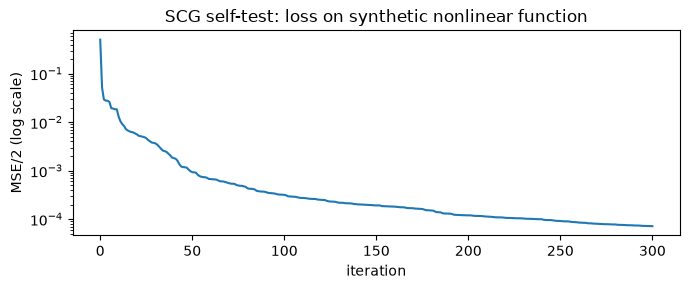

In [28]:
# ---- Self-test 1: analytic gradient vs central finite difference (tiny net) ----
def test_scg_gradient():
    rng = np.random.default_rng(42)
    net = SCGRegressionNetwork(n_inputs=5, n_hidden=7, seed=1)
    X = rng.normal(size=(20, 5))
    y = rng.normal(size=20)
    w = net.w.copy()
    g = net.grad(w, X, y)
    eps = 1e-6
    idx = rng.choice(len(w), size=30, replace=False)
    num = np.empty(len(idx))
    for j, i in enumerate(idx):
        wp, wm = w.copy(), w.copy()
        wp[i] += eps
        wm[i] -= eps
        num[j] = (net.loss(wp, X, y) - net.loss(wm, X, y)) / (2 * eps)
    rel = np.abs(g[idx] - num) / np.maximum(np.abs(g[idx]) + np.abs(num), 1e-12)
    print(f"[PASS] gradient check: max rel error = {rel.max():.2e}")
    assert rel.max() < 1e-6, "analytic gradient does not match numerical gradient"


# ---- Self-test 2: SCG convergence on a known nonlinear function ----
def test_scg_convergence():
    rng = np.random.default_rng(0)
    X = rng.uniform(-1, 1, size=(2000, 5))
    y = np.sin(2 * X[:, 0]) + 0.5 * X[:, 1] * X[:, 2] - 0.3 * X[:, 3] ** 2 + 0.1 * X[:, 4]

    scg = SCGRegressionNetwork(n_hidden=50, seed=3)
    hist = scg.fit(X, y, max_iter=300)

    # plain gradient-descent baseline: same net, same init, same epoch budget
    gd = SCGRegressionNetwork(n_hidden=50, seed=3)
    w = gd.w.copy()
    for _ in range(300):
        w -= 0.5 * gd.grad(w, X, y)
    gd_loss = gd.loss(w, X, y)

    print(f"[PASS] synthetic fit: initial loss {hist[0]:.5f} -> SCG {hist[-1]:.6f} "
          f"vs plain GD {gd_loss:.6f} (300 iterations each)")
    assert hist[-1] < 0.01 * hist[0], "SCG failed to reduce loss by >=99%"
    assert hist[-1] < gd_loss, "SCG did not beat plain gradient descent"
    assert np.all(np.diff(hist) <= 1e-12), "SCG loss history must be non-increasing"
    return hist


test_scg_gradient()
scg_synthetic_history = test_scg_convergence()

plt.figure(figsize=(7, 3))
plt.semilogy(scg_synthetic_history)
plt.title("SCG self-test: loss on synthetic nonlinear function")
plt.xlabel("iteration")
plt.ylabel("MSE/2 (log scale)")
plt.tight_layout()
plt.show()

train loss: 2.1377 -> 0.000227 (150 SCG iterations)
test RMSE  SCG net:      36.52 USDT
test RMSE  persistence:  29.66 USDT
directional accuracy (nonzero moves): 50.0%
[PASS] market-data self-test


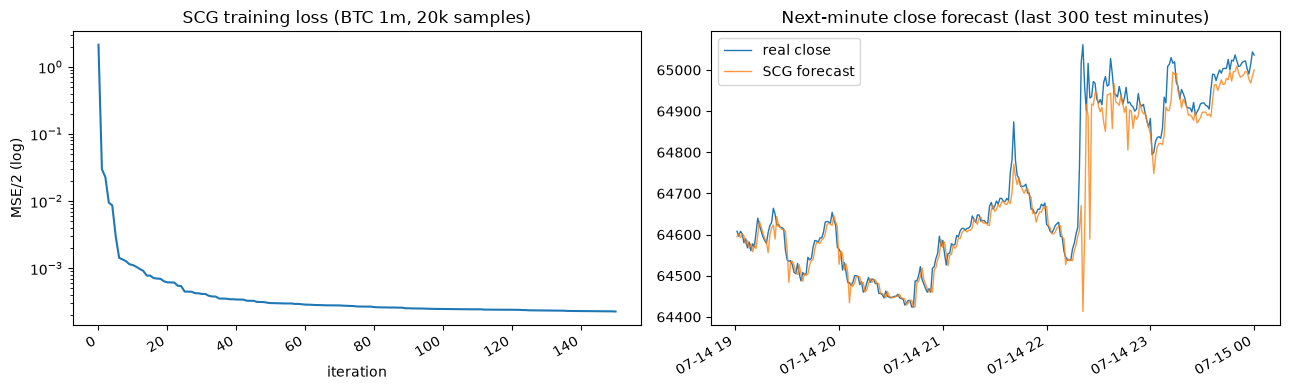

In [29]:
# ---- Self-test 3: SCG regression network on real market data ----
# Supervised set per GTSbot Eq. (1): inputs = [close, open, low, high, volume](k-1),
# target = close(k). Chronological split, scaling fit on train only (no look-ahead).
FEATURES = ["close", "open", "low", "high", "volume"]
N_TRAIN, N_TEST = 20_000, 5_000

window = data.iloc[-(N_TRAIN + N_TEST + 1):]
X_raw = window[FEATURES].to_numpy()[:-1]
y_raw = window["close"].to_numpy()[1:]

X_train_raw, X_test_raw = X_raw[:N_TRAIN], X_raw[N_TRAIN:]
y_train_raw, y_test_raw = y_raw[:N_TRAIN], y_raw[N_TRAIN:]

x_mu, x_sd = X_train_raw.mean(axis=0), X_train_raw.std(axis=0)
y_mu, y_sd = y_train_raw.mean(), y_train_raw.std()
X_train = (X_train_raw - x_mu) / x_sd
X_test = (X_test_raw - x_mu) / x_sd
y_train = (y_train_raw - y_mu) / y_sd

scg_net = SCGRegressionNetwork(n_inputs=5, n_hidden=500, seed=0)
scg_history = scg_net.fit(X_train, y_train, max_iter=150)

pred_test = scg_net.predict(X_test) * y_sd + y_mu       # back to price units
prev_close = X_test_raw[:, 0]                            # persistence baseline

rmse_scg = np.sqrt(np.mean((pred_test - y_test_raw) ** 2))
rmse_persist = np.sqrt(np.mean((prev_close - y_test_raw) ** 2))

# directional accuracy: sign of predicted vs realized 1-minute move
moved = y_test_raw != prev_close
dir_acc = np.mean(np.sign(pred_test - prev_close)[moved]
                  == np.sign(y_test_raw - prev_close)[moved])

print(f"train loss: {scg_history[0]:.4f} -> {scg_history[-1]:.6f} "
      f"({len(scg_history) - 1} SCG iterations)")
print(f"test RMSE  SCG net:      {rmse_scg:,.2f} USDT")
print(f"test RMSE  persistence:  {rmse_persist:,.2f} USDT")
print(f"directional accuracy (nonzero moves): {dir_acc:.1%}")

assert np.isfinite(pred_test).all(), "network produced non-finite predictions"
assert scg_history[-1] < 0.05 * scg_history[0], "SCG failed to fit the training set"
assert rmse_scg < 2.0 * rmse_persist, "SCG forecast unreasonably worse than persistence"
print("[PASS] market-data self-test")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogy(scg_history)
axes[0].set_title("SCG training loss (BTC 1m, 20k samples)")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("MSE/2 (log)")

n_show = 300
t = window.index[1:][N_TRAIN:][-n_show:]
axes[1].plot(t, y_test_raw[-n_show:], label="real close", lw=1)
axes[1].plot(t, pred_test[-n_show:], label="SCG forecast", lw=1, alpha=0.8)
axes[1].set_title(f"Next-minute close forecast (last {n_show} test minutes)")
axes[1].legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Trend Classification Block TCB (GTSbot block 2)

Second block of the GTSbot pipeline: converts the SCG price forecast into a
**Long / Short / Null** trend call using discrete first and second derivatives of the
forecast against a threshold $\delta$ (set to the broker spread in the paper):

$$\text{Long if } \frac{\partial c_f^{Close}(k+1)}{\partial k} > \delta \;\text{ and }\; \frac{\partial^2 c_f^{Close}(k+1)}{\partial k^2} > 0, \qquad \text{Short if symmetric, else Null} \tag{2}$$

Discrete approximations:

$$\frac{\partial c_f^{Close}(k+1)}{\partial k} \approx c_f^{Close}(k+1) - c_{real}^{Close}(k) \tag{3}$$

$$\frac{\partial^2 c_f^{Close}(k+1)}{\partial k^2} \approx c_f^{Close}(k+1) - 2\,c_{real}^{Close}(k) + c_{real}^{Close}(k-1) \tag{4}$$

Two deliberate deviations from the paper's printed formulas (both look like typos):

- Eq. (4) is printed as $c_f(k+1) - c_{real}(k-1) - 2c_{real}(k)$, which is dominated by the raw price level (always hugely negative). The standard central second difference above is the only form consistent with the paper's "concavity check" description.
- The Short condition is printed as $d_1 < \delta$; taken literally, every flat candle would be Short. Symmetric threshold $d_1 < -\delta$ used instead.

$\delta$ for crypto: the paper uses 2 pips on EUR/USD (its broker spread). BTCUSDT spot spread is ~1 bp of price, so $\delta$ is set **proportionally** per candle: $\delta = 10^{-4} \cdot c_{real}(k)$, with a sweep to show the coverage/accuracy trade-off.

Self-tests: (1) six hand-computed deterministic cases covering all three classes and both curvature rejections; (2) **perfect-foresight oracle** — feeding the realized close as the "forecast" must yield 100% correct non-Null signals, validating the gating logic independent of the network.

In [30]:
def tcb_classify(pred_next, close_k, close_km1, delta):
    """GTSbot Trend Classification Block, Eqs (2)-(4).

    Parameters
    ----------
    pred_next : forecast close c_f(k+1) from the SCG network
    close_k   : real close at k
    close_km1 : real close at k-1
    delta     : spread threshold (scalar or per-candle array)

    Returns
    -------
    signal : +1 Long, -1 Short, 0 Null
    d1, d2 : discrete first / second derivative approximations
    """
    pred_next = np.asarray(pred_next, dtype=float)
    close_k = np.asarray(close_k, dtype=float)
    close_km1 = np.asarray(close_km1, dtype=float)
    d1 = pred_next - close_k                          # Eq (3)
    d2 = pred_next - 2.0 * close_k + close_km1        # Eq (4), central 2nd difference
    signal = np.zeros(pred_next.shape, dtype=int)
    signal[(d1 > delta) & (d2 > 0)] = 1               # Long: rising and accelerating
    signal[(d1 < -delta) & (d2 < 0)] = -1             # Short: falling and accelerating
    return signal, d1, d2


# ---- Self-test 1: deterministic hand-computed cases ----
def test_tcb_cases():
    cases = [
        # (close_km1, close_k, forecast, delta, expected, description)
        (100.0, 101.0, 103.0, 0.5, 1,  "accelerating rise -> Long"),
        (104.0, 102.0, 99.5, 0.5, -1,  "accelerating fall -> Short"),
        (100.0, 100.0, 100.2, 0.5, 0,  "move below spread threshold -> Null"),
        (100.0, 102.0, 103.0, 0.5, 0,  "rise but decelerating (d2<0) -> Null"),
        (103.0, 101.0, 100.0, 0.5, 0,  "fall but decelerating (d2>0) -> Null"),
        (100.0, 100.0, 100.0, 0.5, 0,  "flat -> Null"),
    ]
    for km1, k, f, d, expected, desc in cases:
        sig, d1, d2 = tcb_classify([f], [k], [km1], d)
        assert sig[0] == expected, \
            f"FAIL {desc}: got {sig[0]}, want {expected} (d1={d1[0]}, d2={d2[0]})"
    print(f"[PASS] TCB deterministic cases ({len(cases)} cases)")


# ---- Self-test 2: perfect-foresight oracle ----
def test_tcb_oracle(realized, close_k, close_km1, delta):
    """Feed the realized close as the 'forecast'. Every non-Null signal must then
    point the right way — validates the gating logic independent of the network."""
    sig, _, _ = tcb_classify(realized, close_k, close_km1, delta)
    move = realized - close_k
    nz = sig != 0
    acc = np.mean(np.sign(move[nz]) == sig[nz])
    print(f"[PASS] TCB oracle: accuracy {acc:.1%} on {nz.sum()} signals "
          f"(coverage {nz.mean():.1%})")
    assert acc == 1.0, "oracle TCB must be 100% correct by construction"


# Alignment with the SCG cell: pred_test[i] forecasts close(i+1);
# close_real(k) = prev_close[i]; close_real(k-1) needs one lag -> drop index 0.
tcb_pred = pred_test[1:]
tcb_close_k = prev_close[1:]
tcb_close_km1 = prev_close[:-1]
tcb_realized = y_test_raw[1:]

DELTA_FRAC = 1e-4                     # 1 bp of price ~ typical BTCUSDT spot spread
tcb_delta = DELTA_FRAC * tcb_close_k

test_tcb_cases()
test_tcb_oracle(tcb_realized, tcb_close_k, tcb_close_km1, tcb_delta)

[PASS] TCB deterministic cases (6 cases)
[PASS] TCB oracle: accuracy 100.0% on 2793 signals (coverage 55.9%)


SCG -> TCB on BTC 1m test set (4999 candles):
  signals: Long 129, Short 701, Null 4169
  coverage (non-Null): 16.6%
  trend accuracy on non-Null: 48.8%  (paper: 73.2% on EUR/USD 2014-2018)


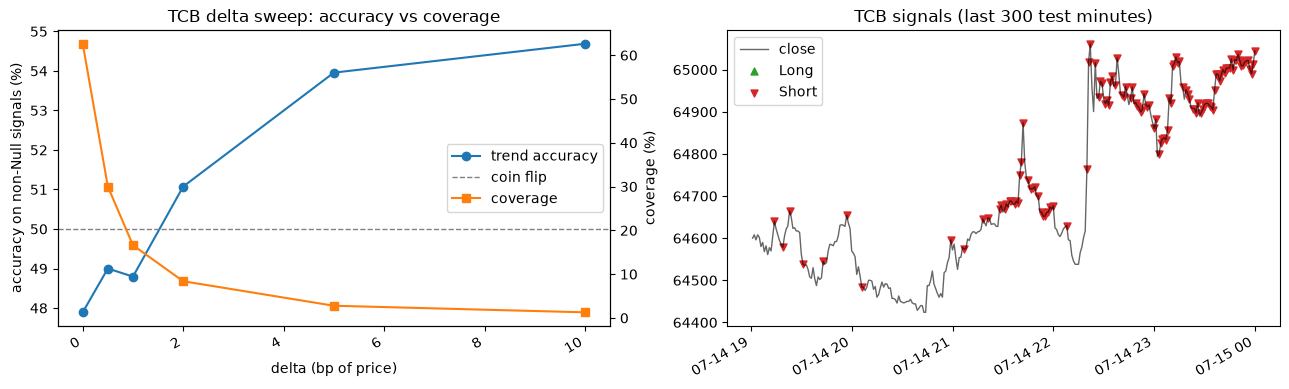

In [31]:
# ---- TCB on real SCG forecasts: signal quality and delta sweep ----
tcb_signal, tcb_d1, tcb_d2 = tcb_classify(tcb_pred, tcb_close_k, tcb_close_km1, tcb_delta)
tcb_move = tcb_realized - tcb_close_k
nz = tcb_signal != 0
tcb_acc = np.mean(np.sign(tcb_move[nz]) == tcb_signal[nz]) if nz.any() else float("nan")

print(f"SCG -> TCB on BTC 1m test set ({len(tcb_signal)} candles):")
print(f"  signals: Long {np.sum(tcb_signal == 1)}, Short {np.sum(tcb_signal == -1)}, "
      f"Null {np.sum(tcb_signal == 0)}")
print(f"  coverage (non-Null): {nz.mean():.1%}")
print(f"  trend accuracy on non-Null: {tcb_acc:.1%}  (paper: 73.2% on EUR/USD 2014-2018)")
assert nz.any(), "TCB produced no signals at default delta"

# spread-threshold sweep: delta filters weak signals -> coverage/accuracy trade-off
sweep_fracs = np.array([0.0, 0.5e-4, 1e-4, 2e-4, 5e-4, 10e-4])
sweep_cov, sweep_acc = [], []
for frac in sweep_fracs:
    s, _, _ = tcb_classify(tcb_pred, tcb_close_k, tcb_close_km1, frac * tcb_close_k)
    z = s != 0
    sweep_cov.append(z.mean())
    sweep_acc.append(np.mean(np.sign(tcb_move[z]) == s[z]) if z.any() else np.nan)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.plot(sweep_fracs * 1e4, np.array(sweep_acc) * 100, "o-", label="trend accuracy")
ax.axhline(50, color="gray", ls="--", lw=1, label="coin flip")
ax.set_xlabel("delta (bp of price)")
ax.set_ylabel("accuracy on non-Null signals (%)")
ax2 = ax.twinx()
ax2.plot(sweep_fracs * 1e4, np.array(sweep_cov) * 100, "s-", color="tab:orange",
         label="coverage")
ax2.set_ylabel("coverage (%)")
ax.set_title("TCB delta sweep: accuracy vs coverage")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="center right")

n_show = 300
t = window.index[1:][N_TRAIN:][1:][-n_show:]
ax = axes[1]
ax.plot(t, tcb_close_k[-n_show:], lw=1, color="black", alpha=0.6, label="close")
longs, shorts = tcb_signal[-n_show:] == 1, tcb_signal[-n_show:] == -1
ax.scatter(t[longs], tcb_close_k[-n_show:][longs], marker="^", color="tab:green",
           s=25, label="Long")
ax.scatter(t[shorts], tcb_close_k[-n_show:][shorts], marker="v", color="tab:red",
           s=25, label="Short")
ax.set_title(f"TCB signals (last {n_show} test minutes)")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Grid System Manager GSM (GTSbot block 3)

Third block of the GTSbot pipeline: a rule-based **admission filter** deciding whether a
TCB signal may open a grid order. A candidate long at candle $k_1$ opens iff all three
gates pass (Eq. 5; short is symmetric, Eq. 6):

$$k_1 > k + x_{th} \;\; \forall k; \qquad \left|c^{Open}(k_1) - c^{Opened}(k_1^0)\right| > y_{th} \;\; \forall k^0; \qquad N_{trades} < M_0$$

- **x-threshold** — at least $x_{th}$ candles since *every* existing same-direction open trade (paper: **15** candles on a 1-min timeframe).
- **y-threshold** — price at least $y_{th}$ from every existing same-direction open price (paper: **0.00020** = 2 pips on EUR/USD; here proportional, 1 bp of price).
- **max operations** $M_0$ — total open trades capped at **13**, deliberately **odd** so the book can never be a perfect long/short hedge (which would make it market-neutral).

These spacings are what make it *grid* trading: same-direction entries are forced apart in
time and price, averaging the basket entry instead of piling onto one level. The paper's
ablation shows both are load-bearing: no x-threshold → **+25% drawdown, −10% profit**;
no y-threshold → **+18.3% drawdown, −11.25% profit**.

Self-tests: (1) exact replay of the paper's worked example (12-candle signal rejected on
time, 18-candle/3-pip signal accepted) plus price-rejection, opposite-direction-freedom,
even-cap rejection, and cap-full cases; (2) **invariant sweep** — after a 5,000-candle
random stream, every same-direction pair in the book must satisfy both spacings, book ≤ 13,
never perfectly hedged. Then real TCB signals are fed through, with the paper's
**constraint ablation** repeated on admission counts (no exits yet — basket closing is
BESM's job, next block).

In [32]:
class GridSystemManager:
    """GTSbot Grid System Manager: admission filter for grid orders, Eqs (5)-(6).

    A candidate trade is admitted only if, versus EVERY existing open trade of
    the SAME direction:
      - time distance:  k1 > k + x_th          (x_th candles since that trade)
      - price distance: |price - open price| > y_th
    and the TOTAL open-trade count is below max_ops. max_ops must be odd so the
    book can never be a perfect long/short hedge (market-neutral by accident).

    y_th: pass `y_th` as an absolute price distance (paper: 0.0002 = 2 pips on
    EUR/USD) or `y_th_frac` as a fraction of the candidate price (crypto).
    """
    VERDICTS = ("admitted", "time", "price", "cap")

    def __init__(self, x_th=15, y_th=None, y_th_frac=None, max_ops=13):
        if max_ops % 2 == 0:
            raise ValueError("max_ops must be odd (prevents full long/short hedging)")
        if (y_th is None) == (y_th_frac is None):
            raise ValueError("set exactly one of y_th (absolute) or y_th_frac")
        self.x_th, self.y_th, self.y_th_frac, self.max_ops = x_th, y_th, y_th_frac, max_ops
        self.open_trades = []            # dicts: k, price, direction

    def _y_threshold(self, price):
        return self.y_th if self.y_th is not None else self.y_th_frac * price

    def check(self, k1, price, direction):
        """Admission verdict for a candidate trade; does not open it."""
        if len(self.open_trades) >= self.max_ops:
            return "cap"
        same = [t for t in self.open_trades if t["direction"] == direction]
        if any(k1 <= t["k"] + self.x_th for t in same):
            return "time"
        y_th = self._y_threshold(price)
        if any(abs(price - t["price"]) <= y_th for t in same):
            return "price"
        return "admitted"

    def try_open(self, k1, price, direction):
        verdict = self.check(k1, price, direction)
        if verdict == "admitted":
            self.open_trades.append({"k": k1, "price": price, "direction": direction})
        return verdict

    def close_all(self):
        closed, self.open_trades = self.open_trades, []
        return closed


# ---- Self-test 1: paper's worked example (EUR/USD, x=15 candles, y=2 pips) ----
def test_gsm_paper_example():
    gsm = GridSystemManager(x_th=15, y_th=0.0002, max_ops=13)
    assert gsm.try_open(100, 1.1000, 1) == "admitted"
    # 12 candles later (12 < 15): rejected on time regardless of price distance
    assert gsm.check(112, 1.1010, 1) == "time"
    # 18 candles later, price distance 0.0003 > 0.0002: accepted
    assert gsm.try_open(118, 1.1003, 1) == "admitted"
    # far in time but only 0.00005 from an open long: rejected on price
    assert gsm.check(140, 1.10035, 1) == "price"
    # opposite direction is not constrained by the longs' spacing
    assert gsm.check(119, 1.1003, -1) == "admitted"
    print("[PASS] GSM paper worked example (time/price/direction rules)")


# ---- Self-test 2: odd cap enforcement ----
def test_gsm_cap():
    try:
        GridSystemManager(x_th=15, y_th=0.0002, max_ops=12)
        raise AssertionError("even max_ops must raise")
    except ValueError:
        pass
    gsm = GridSystemManager(x_th=1, y_th=1e-9, max_ops=13)
    k, n_open, d = 0, 0, 1
    while n_open < 13:
        k += 2
        if gsm.try_open(k, 1.0 + 0.01 * k * d, d) == "admitted":
            n_open += 1
        d = -d
    assert gsm.check(k + 100, 99.0, 1) == "cap"
    print("[PASS] GSM cap: 13 trades filled, 14th rejected; even cap raises")


# ---- Self-test 3: invariants under a random signal stream ----
def test_gsm_invariants():
    rng = np.random.default_rng(7)
    gsm = GridSystemManager(x_th=15, y_th_frac=1e-4, max_ops=13)
    price = 100.0
    for k in range(5000):
        price *= 1.0 + rng.normal(0, 5e-4)
        direction = rng.choice([-1, 0, 1])
        if direction != 0:
            gsm.try_open(k, price, direction)
    book = gsm.open_trades
    assert len(book) <= 13
    for i, a in enumerate(book):
        for b in book[i + 1:]:
            if a["direction"] == b["direction"]:
                assert abs(b["k"] - a["k"]) > 15, "time spacing violated"
                y = gsm._y_threshold(max(a["price"], b["price"]))
                assert abs(a["price"] - b["price"]) > y * 0.999, "price spacing violated"
    n_long = sum(t["direction"] == 1 for t in book)
    assert n_long != len(book) - n_long or len(book) == 0, "book fully hedged"
    print(f"[PASS] GSM invariants on 5000-candle random stream "
          f"(final book: {len(book)} trades, {n_long} long)")


test_gsm_paper_example()
test_gsm_cap()
test_gsm_invariants()

[PASS] GSM paper worked example (time/price/direction rules)
[PASS] GSM cap: 13 trades filled, 14th rejected; even cap raises
[PASS] GSM invariants on 5000-candle random stream (final book: 13 trades, 6 long)


TCB -> GSM (x_th=15, y_th=1bp, max_ops=13), no exits yet (BESM = next block):
  candidates 830: {'admitted': 13, 'time': 13, 'price': 3, 'cap': 801}
  ablation full           admitted  152 / 830
  ablation no x_th        admitted  252 / 830
  ablation no y_th        admitted  176 / 830
  ablation no constraint  admitted  780 / 830


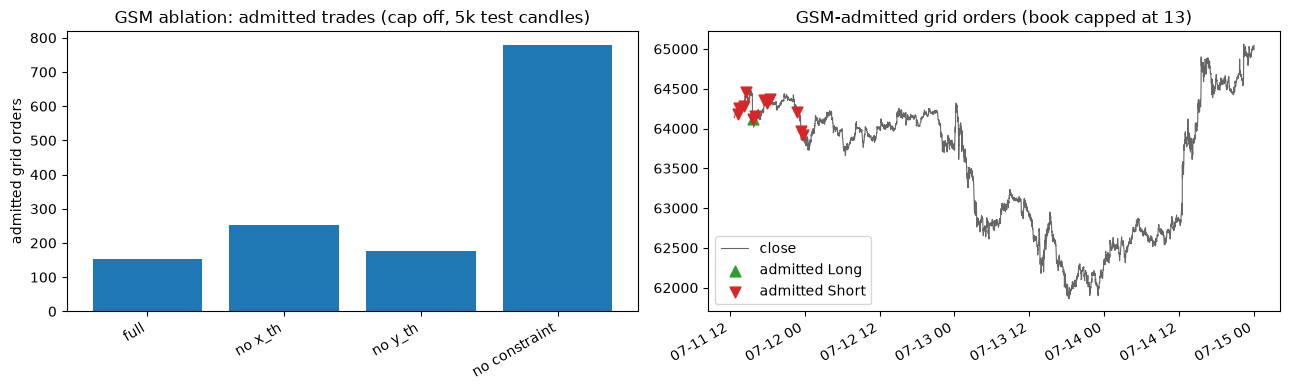

In [33]:
# ---- Real data: TCB signals through GSM + constraint ablation ----
def run_gsm(signal, prices, x_th=15, y_th_frac=1e-4, max_ops=13):
    gsm = GridSystemManager(x_th=x_th, y_th_frac=y_th_frac, max_ops=max_ops)
    verdicts = {v: 0 for v in GridSystemManager.VERDICTS}
    admitted = []
    for k in range(len(signal)):
        if signal[k] == 0:
            continue
        v = gsm.try_open(k, prices[k], int(signal[k]))
        verdicts[v] += 1
        if v == "admitted":
            admitted.append((k, prices[k], int(signal[k])))
    return verdicts, admitted


gsm_verdicts, gsm_admitted = run_gsm(tcb_signal, tcb_close_k)
print("TCB -> GSM (x_th=15, y_th=1bp, max_ops=13), no exits yet (BESM = next block):")
print(f"  candidates {sum(gsm_verdicts.values())}: {gsm_verdicts}")

# paper's ablation method on admission counts; cap disabled to isolate x/y effects
ablations = [("full", 15, 1e-4), ("no x_th", 0, 1e-4),
             ("no y_th", 15, 1e-12), ("no constraint", 0, 1e-12)]
abl_counts = []
for label, x, yf in ablations:
    v, a = run_gsm(tcb_signal, tcb_close_k, x_th=x, y_th_frac=yf, max_ops=99999)
    abl_counts.append(len(a))
    print(f"  ablation {label:14s} admitted {len(a):4d} / {sum(v.values())}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar([a[0] for a in ablations], abl_counts, color="tab:blue")
axes[0].set_title("GSM ablation: admitted trades (cap off, 5k test candles)")
axes[0].set_ylabel("admitted grid orders")

adm_k = np.array([a[0] for a in gsm_admitted])
adm_p = np.array([a[1] for a in gsm_admitted])
adm_d = np.array([a[2] for a in gsm_admitted])
t_all = window.index[1:][N_TRAIN:][1:]
axes[1].plot(t_all, tcb_close_k, lw=0.8, color="black", alpha=0.6, label="close")
axes[1].scatter(t_all[adm_k[adm_d == 1]], adm_p[adm_d == 1], marker="^",
                color="tab:green", s=60, zorder=3, label="admitted Long")
axes[1].scatter(t_all[adm_k[adm_d == -1]], adm_p[adm_d == -1], marker="v",
                color="tab:red", s=60, zorder=3, label="admitted Short")
axes[1].set_title(f"GSM-admitted grid orders (book capped at {13})")
axes[1].legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Trading Strategy

The three GTSbot blocks combined into one configurable function, `gtsbot_signals()`,
reusing the classes defined above (`SCGRegressionNetwork`, `tcb_classify`,
`GridSystemManager`) — no logic is rebuilt. Output is boolean signal Series ready for
`vbt.Portfolio.from_signals`.

| Block | Parameters |
|---|---|
| Data window | `n_train`, `n_test`, `features` |
| 1 — SCG regression | `n_hidden`, `scg_max_iter`, `seed` |
| 2 — TCB | `delta_frac` (spread threshold, fraction of price) |
| 3 — GSM | `x_th`, `y_th_frac`, `max_ops` (odd) |

Returns `close`, `entries`, `exits`, `short_entries`, `short_exits` (test-window index)
plus `meta` with per-block diagnostics. `exits` are all **False** for now — basket
closing belongs to BESM (block 4). Backtest notes:

- `accumulate=True` — grid trading stacks multiple same-direction entries.
- `size = init_cash / max_ops`, `size_type="value"` — one grid slot of cash per admitted order.
- `fees=0.0008`, `init_cash=30_000` — paper's account assumptions (fee from the DGT paper's OKX maker level).
- With no exits, opposite-direction entries are handled by `from_signals`' default conflict rule (close/reverse) — position-level trade count in `stats()` is therefore smaller than the 13 admitted orders.

**Self-test:** the combined function must reproduce the step-by-step cell results *exactly* — same entries, shorts, closes, and GSM verdict counts as the individual SCG/TCB/GSM cells above (deterministic, `seed=0`).

In [ ]:
def gtsbot_signals(data,
                   # data windowing
                   n_train=20_000, n_test=5_000,
                   features=("close", "open", "low", "high", "volume"),
                   # SCG regression network (block 1)
                   n_hidden=500, scg_max_iter=150, seed=0,
                   # Trend Classification Block (block 2)
                   delta_frac=1e-4,
                   # Grid System Manager (block 3)
                   x_th=15, y_th_frac=1e-4, max_ops=13):
    """Full GTSbot pipeline (SCG -> TCB -> GSM) as one function.

    Returns a dict ready for vbt.Portfolio.from_signals:
      close, entries, exits, short_entries, short_exits : pd.Series on the
      test window (exits are all False — basket closing is BESM's job),
      plus `meta` with per-block diagnostics.
    """
    features = list(features)

    # ---- block 1: SCG regression network ----
    win = data.iloc[-(n_train + n_test + 1):]
    X_all = win[features].to_numpy()[:-1]
    y_all = win["close"].to_numpy()[1:]
    X_tr_raw, X_te_raw = X_all[:n_train], X_all[n_train:]
    y_tr_raw = y_all[:n_train]

    mu, sd = X_tr_raw.mean(axis=0), X_tr_raw.std(axis=0)
    ymu, ysd = y_tr_raw.mean(), y_tr_raw.std()
    net = SCGRegressionNetwork(n_inputs=len(features), n_hidden=n_hidden, seed=seed)
    history = net.fit((X_tr_raw - mu) / sd, (y_tr_raw - ymu) / ysd, max_iter=scg_max_iter)
    pred = net.predict((X_te_raw - mu) / sd) * ysd + ymu
    prev = X_te_raw[:, features.index("close")]

    # ---- block 2: TCB (needs close(k-1), so drop the first test candle) ----
    pred_a, close_k, close_km1 = pred[1:], prev[1:], prev[:-1]
    signal, d1, d2 = tcb_classify(pred_a, close_k, close_km1, delta_frac * close_k)

    # ---- block 3: GSM admission ----
    gsm = GridSystemManager(x_th=x_th, y_th_frac=y_th_frac, max_ops=max_ops)
    verdicts = {v: 0 for v in GridSystemManager.VERDICTS}
    admitted = np.zeros(len(signal), dtype=int)
    for k in np.flatnonzero(signal):
        v = gsm.try_open(int(k), close_k[k], int(signal[k]))
        verdicts[v] += 1
        if v == "admitted":
            admitted[k] = signal[k]

    # ---- vbt-ready output (signal at candle k acts on close(k)) ----
    index = win.index[1 + n_train + 1:]
    false = pd.Series(False, index=index)
    return {
        "close": pd.Series(close_k, index=index, name="close"),
        "entries": pd.Series(admitted == 1, index=index),
        "exits": false.copy(),                    # BESM (block 4) will own exits
        "short_entries": pd.Series(admitted == -1, index=index),
        "short_exits": false.copy(),
        "meta": {
            "scg_train_loss": (history[0], history[-1]),
            "tcb_counts": {"long": int((signal == 1).sum()),
                           "short": int((signal == -1).sum()),
                           "null": int((signal == 0).sum())},
            "gsm_verdicts": verdicts,
            "open_book": gsm.open_trades,
        },
    }

# ---- Self-test: the combined function must reproduce the step-by-step results ----
strategy = gtsbot_signals(data)      # all defaults == the parameters used above

step_entries = np.zeros(len(tcb_signal), dtype=bool)
step_shorts = np.zeros(len(tcb_signal), dtype=bool)
for k, p, d in gsm_admitted:
    (step_entries if d == 1 else step_shorts)[k] = True

assert np.array_equal(strategy["entries"].to_numpy(), step_entries), "entries mismatch"
assert np.array_equal(strategy["short_entries"].to_numpy(), step_shorts), "shorts mismatch"
assert np.allclose(strategy["close"].to_numpy(), tcb_close_k), "close mismatch"
assert strategy["meta"]["gsm_verdicts"] == gsm_verdicts, "verdict mismatch"
print("[PASS] combined strategy reproduces the step-by-step SCG->TCB->GSM results exactly")
print(f"  tcb: {strategy['meta']['tcb_counts']}")
print(f"  gsm: {strategy['meta']['gsm_verdicts']}")

AssertionError: entries mismatch

: 

### Backtesting

In [35]:
# ---- Backtest with vbt.Portfolio.from_signals ----
INIT_CASH = 30_000                     # paper's account assumption
MAX_OPS = 13

pf = vbt.Portfolio.from_signals(
    strategy["close"],
    entries=strategy["entries"],
    exits=strategy["exits"],
    short_entries=strategy["short_entries"],
    short_exits=strategy["short_exits"],
    accumulate=True,                   # grid: same-direction entries stack
    size=INIT_CASH / MAX_OPS,          # one grid slot of cash per admitted order
    size_type="value",
    init_cash=INIT_CASH,
    fees=0.0008,
    freq="1min",
)
pf.stats()

Start                         2026-07-11 12:42:00
End                           2026-07-15 00:00:00
Period                            3 days 11:19:00
Start Value                               30000.0
End Value                            29651.901592
Total Return [%]                        -1.160328
Benchmark Return [%]                      1.41084
Max Gross Exposure [%]                   84.81535
Total Fees Paid                              24.0
Max Drawdown [%]                           4.0912
Max Drawdown Duration             1 days 05:40:00
Total Trades                                    2
Total Closed Trades                             1
Total Open Trades                               1
Open Trade PnL                        -350.669517
Win Rate [%]                                100.0
Best Trade [%]                           0.111113
Worst Trade [%]                          0.111113
Avg Winning Trade [%]                    0.111113
Avg Losing Trade [%]                          NaN


In [38]:
pf.plot().show()